# Notebook Overview: The Data Selection Showdown
**Objective:** Mathematically prove whether LLM Active Learning (`Gemma-3-4b-it` + K-Means) actually beats just giving SetFit 50 raw samples.

In [1]:
# Colab setup: install dependencies, mount Drive, and load secrets.
%pip install -q --upgrade pip
%pip install -q pandas numpy scikit-learn datasets fastembed openai setfit sentence-transformers accelerate "transformers<5" tqdm

import os
from pathlib import Path

try:
    from google.colab import drive, userdata
except Exception:
    drive = None
    userdata = None

if drive is not None:
    drive.mount("/content/drive", force_remount=False)

def _secret(name: str) -> str | None:
    if userdata is not None:
        try:
            value = userdata.get(name)
            if value:
                return str(value)
        except Exception:
            pass
    value = os.getenv(name)
    return str(value) if value else None

GOOGLE_API_KEY = _secret("GOOGLE_API_KEY")
if not GOOGLE_API_KEY:
    raise ValueError("Set GOOGLE_API_KEY in Colab Secrets or environment before running the notebook.")
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY
os.environ["GEMINI_API_KEY"] = GOOGLE_API_KEY

HF_TOKEN = _secret("HF_TOKEN")
if HF_TOKEN:
    os.environ["HF_TOKEN"] = HF_TOKEN
    os.environ["HUGGINGFACEHUB_API_TOKEN"] = HF_TOKEN

SEED = int(os.getenv("SEED", "42"))
os.environ["SEED"] = str(SEED)

SAVE_ROOT = Path("/content/drive/MyDrive/data_selection_showdown")
if not SAVE_ROOT.parent.exists():
    SAVE_ROOT = Path("/content/data_selection_showdown")

RESULTS_DIR = SAVE_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
os.environ["RESULTS_DIR"] = str(RESULTS_DIR)
os.environ["HF_HOME"] = str(SAVE_ROOT / ".hf")
os.environ["HF_DATASETS_CACHE"] = str(SAVE_ROOT / ".hf" / "datasets")
os.environ["TRANSFORMERS_CACHE"] = str(SAVE_ROOT / ".hf" / "transformers")

print(f"Drive mounted: {Path('/content/drive/MyDrive').exists()}")
print(f"Results dir: {RESULTS_DIR}")
print(f"Seed: {SEED}")
print("Google API key:", "set" if GOOGLE_API_KEY else "missing")
print("HF token:", "set" if HF_TOKEN else "unset")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 30.7 MB/s eta 0:00:00
Mounted at /content/drive
Drive mounted: True
Results dir: /content/drive/MyDrive/data_selection_showdown/results
Seed: 42
Google API key: set
HF token: unset


## Cell 1: Dependencies & Initialization

In [2]:
from __future__ import annotations

import gc
import json
import os
import re
import sys
import traceback
import warnings
from collections import Counter
from datetime import datetime, timezone
from pathlib import Path
from time import perf_counter

import numpy as np
import pandas as pd
import torch
import transformers
from datasets import Dataset as HFDataset
from datasets import Features, load_dataset
from fastembed import TextEmbedding
from openai import OpenAI
from setfit import SetFitModel, Trainer as SetFitTrainer, TrainingArguments as SetFitArgs
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# Google Gemini via the OpenAI-compatible Google endpoint.
GEMMA_MODEL = "gemma-3-4b-it"
GOOGLE_OPENAI_BASE_URL = "https://generativelanguage.googleapis.com/v1beta/openai/"
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
HF_TOKEN = os.getenv("HF_TOKEN")
if not GOOGLE_API_KEY:
    raise ValueError("GOOGLE_API_KEY is not set. Run the Colab setup cell and add the secret.")

client = OpenAI(
    api_key=GOOGLE_API_KEY,
    base_url=GOOGLE_OPENAI_BASE_URL,
    max_retries=30,
 )

# FastEmbed keeps the embedding path aligned with the rest of the repo.
FASTEMBED_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
embedder = TextEmbedding(model_name=FASTEMBED_MODEL)

PROMPT_LABELS = ["not irony", "irony"]
LABEL_TO_ID = {label: idx for idx, label in enumerate(PROMPT_LABELS)}

def embed_texts(texts: list[str]) -> np.ndarray:
    vectors = [np.asarray(vector, dtype=np.float32) for vector in embedder.embed(texts)]
    return np.vstack(vectors) if vectors else np.zeros((0, 384), dtype=np.float32)

SEED = int(os.getenv("SEED", "42"))
np.random.seed(SEED)

# Colab-friendly output directory (Drive when mounted, /content fallback otherwise).
RESULTS_DIR = Path(os.getenv("RESULTS_DIR", "/content/results"))
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
os.environ["RESULTS_DIR"] = str(RESULTS_DIR)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Seed: {SEED}")
print(f"Results dir: {RESULTS_DIR}")
if HF_TOKEN:
    print("HF token: set")

# Global results accumulator
ALL_RESULTS: list[dict] = []

def now_stamp() -> str:
    return datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")

def save_result(result: dict):
    """Append a result dict and save incrementally to JSON."""
    ALL_RESULTS.append(result)
    path = RESULTS_DIR / "results_incremental.json"
    path.write_text(json.dumps(ALL_RESULTS, indent=2, default=str))
    status = result.get("error", None)
    tag = "ERR" if status else "OK"
    print(f"  [{tag}] Saved {len(ALL_RESULTS)} results -> {path.name}")

/usr/local/lib/python3.12/dist-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/650 [00:00<?, ?B/s]

model.onnx:   0%|          | 0.00/90.4M [00:00<?, ?B/s]

Device: cuda
GPU: Tesla T4
Seed: 42
Results dir: /content/drive/MyDrive/data_selection_showdown/results


## Cell 2: Data Ingestion

In [ ]:
dataset = load_dataset('tweet_eval', 'irony')
df_train = dataset['train'].to_pandas()
df_test = dataset['test'].to_pandas()

print(f"--- Data Ingestion --- ")
print(f"Train Set Size: {len(df_train)}")
print(f"Test Set Size: {len(df_test)}")
print(f"Label Distribution:\n{df_train['label'].value_counts(normalize=True)}")

--- Data Ingestion --- 
Train Set Size: 2862
Test Set Size: 784
Label Distribution:
label
1    0.504892
0    0.495108
Name: proportion, dtype: float64


## Experiment 1: The "10-to-100" LLM Bootstrapping Pipeline
### Cell 3: The Initial Seed (N=20)

In [ ]:
# Randomly sample 20 stratified rows from df_train (10 irony, 10 not irony)
df_seed_20 = df_train.groupby('label').sample(n=10, random_state=42)

# Remove these 20 rows from df_train to create df_unlabeled_pool
df_unlabeled_pool = df_train.drop(df_seed_20.index)

print(f"--- Seed Selection --- ")
print(f"Seed Size: {len(df_seed_20)}")
print(f"Unlabeled Pool Size: {len(df_unlabeled_pool)}")

--- Seed Selection --- 
Seed Size: 20
Unlabeled Pool Size: 2842


In [ ]:
# Train initial SetFit on 20-sample seed
train_ds_seed = HFDataset.from_pandas(df_seed_20[['text', 'label']])
setfit_seed = SetFitModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
args_seed = SetFitArgs(batch_size=16, num_epochs=1, evaluation_strategy="no", save_strategy="no")
trainer_seed = SetFitTrainer(model=setfit_seed, args=args_seed, train_dataset=train_ds_seed)
trainer_seed.train()
print("Initial Seed SetFit (N=20) trained.")

model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.
The `evaluation_strategy` argument is deprecated and will be removed in a future version. Please use `eval_strategy` instead.


Map:   0%|          | 0/20 [00:00<?, ? examples/s]

***** Running training *****
  Num unique pairs = 220
  Batch size = 16
  Num epochs = 1


Step,Training Loss
1,0.370000


Initial Seed SetFit (N=20) trained.


### Cell 4: Deterministic Cleaners (The Bouncer)

In [ ]:
URL_OR_MENTION_RE = re.compile(r"(?:https?://\S+|www\.\S+|@\w+)", re.IGNORECASE)

def is_clean(text):
    text = str(text).strip()
    if len(text) < 15:
        return False

    tokens = re.findall(r"\S+", text)
    if not tokens:
        return False

    noisy_tokens = len(URL_OR_MENTION_RE.findall(text))
    return (noisy_tokens / len(tokens)) <= 0.5

df_clean_pool = df_unlabeled_pool[df_unlabeled_pool['text'].apply(is_clean)].copy()
print("Clean pool size:", len(df_clean_pool))

Clean pool size: 2804


### Cell 5: Embedding & K-Means (The Map Maker)

In [ ]:
import umap
from sklearn.metrics import pairwise_distances_argmin_min

print(f"--- Embedding & Clustering --- ")
# Embed the text column of df_clean_pool
embeddings = embed_texts(df_clean_pool['text'].astype(str).tolist())
print(f"Generated embeddings shape: {embeddings.shape}")

# Apply UMAP
reducer = umap.UMAP(n_components=10, random_state=42, n_neighbors=15, metric='cosine')
embeddings_reduced = reducer.fit_transform(embeddings)

# Run K-Means
kmeans = KMeans(n_clusters=80, random_state=42, n_init=10)
kmeans.fit(embeddings_reduced)

# Extract centroids
closest, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_, embeddings_reduced)
df_centroids = df_clean_pool.iloc[closest].copy()

print(f"K-Means complete. Selected {len(df_centroids)} centroids from the clean pool.")

Centroids selected: 80


### Cell 6: LLM Labeling & Confidence Filter

In [ ]:
import json
from tqdm.auto import tqdm

def get_batch_label_prompt(batch_texts):
    prompt = """Classify the following tweets into exactly one label: irony or not irony.
Return the result EXCLUSIVELY as a JSON list of objects:
[{\"label\": \"...\"}, ...]

Tweets to classify:
"""
    for i, txt in enumerate(batch_texts):
        prompt += f"\n{i+1}. {txt}"
    return prompt

def batch_label_gemma(batch_texts):
    try:
        response = client.chat.completions.create(
            model=GEMMA_MODEL,
            messages=[{"role": "user", "content": get_batch_label_prompt(batch_texts)}],
            temperature=0.1,
            max_tokens=256
        )
        content = response.choices[0].message.content or "[]"
        # Clean potential markdown backticks from LLM output
        content = content.replace('```json', '').replace('```', '').strip()
        return json.loads(content)
    except Exception as e:
        print(f"Error: {e}")
        return []

print("LLM Batch Labeling Step - Prompting Gemma...")

batch_size = 5
texts = df_centroids["text"].astype(str).tolist()
llm_results = []

for i in tqdm(range(0, len(texts), batch_size), desc="Gemma labeling"):
    batch = texts[i : i + batch_size]
    res = batch_label_gemma(batch)
    if isinstance(res, list):
        llm_results.extend(res)
    elif isinstance(res, dict) and "results" in res:
        llm_results.extend(res["results"])

# Map results to dataframe rows
labels_found = [r.get("label", "").lower() for r in llm_results]
df_centroids["llm_label"] = labels_found[:len(df_centroids)]

# Keep only rows with valid labels, then map to training IDs
df_accepted = df_centroids[df_centroids["llm_label"].isin(PROMPT_LABELS)].copy()
df_accepted["label"] = df_accepted["llm_label"].map(LABEL_TO_ID).astype(int)

df_llm_boosted_train = pd.concat([df_seed_20, df_accepted[["text", "label"]]], ignore_index=True)

print("Accepted centroids:", len(df_accepted))
print("Boosted Exp1 Train size:", len(df_llm_boosted_train))

LLM Batch Labeling Step - Prompting Gemma...


Gemma labeling:   0%|          | 0/16 [00:00<?, ?it/s]

Accepted centroids: 80
Boosted Exp1 Train size: 100


In [ ]:
# 1. Get predictions from the seed model for the centroids
centroid_texts = df_centroids['text'].tolist()
seed_preds = setfit_seed.predict(centroid_texts)
df_centroids['seed_label'] = seed_preds

# 2. Filter for agreement between Seed SetFit and Gemma (llm_label)
# Note: llm_label is already mapped to numeric IDs in df_accepted in the previous cell
# We re-verify agreement here
df_consensus = df_centroids[df_centroids['seed_label'] == df_centroids['label']].copy()

# 3. Combine initial seed + consensus centroids
df_exp1_representative_train = pd.concat([df_seed_20, df_consensus[['text', 'label']]], ignore_index=True)

print(f"Agreement found in {len(df_consensus)} out of {len(df_centroids)} centroids.")
print(f"Final 'setfit_representative' training size: {len(df_exp1_representative_train)}")

Agreement found in 39 out of 80 centroids.
Final 'setfit_representative' training size: 59


In [ ]:
# Train the final representative model for Experiment 1 (Consensus-based)
# This model uses only the samples where the 20-seed SetFit and Gemma agreed.
train_ds_rep = HFDataset.from_pandas(df_exp1_representative_train[['text', 'label']])
setfit_representative = SetFitModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")

# Using the same hyperparameters for a fair comparison
args_rep = SetFitArgs(batch_size=16, num_epochs=3, evaluation_strategy="no", save_strategy="no")
trainer_rep = SetFitTrainer(model=setfit_representative, args=args_rep, train_dataset=train_ds_rep)

print(f"--- Training Representative (Consensus) SetFit --- ")
print(f"Training on {len(df_exp1_representative_train)} samples (20 seed + {len(df_consensus)} agreed centroids)...")
trainer_rep.train()

# Explicitly naming this to avoid confusion with the 100-sample boosted model
setfit_consensus = setfit_representative
print("setfit_consensus training finished.")

model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.
The `evaluation_strategy` argument is deprecated and will be removed in a future version. Please use `eval_strategy` instead.


Map:   0%|          | 0/59 [00:00<?, ? examples/s]

***** Running training *****
  Num unique pairs = 1824
  Batch size = 16
  Num epochs = 3


--- Training Representative (Consensus) SetFit --- 
Training on 59 samples (20 seed + 39 agreed centroids)...


Step,Training Loss
1,0.381000
50,0.279200
100,0.202500
150,0.040600
200,0.007200
250,0.004300
300,0.003500


setfit_consensus training finished.


### Cell 8: Ensemble Pseudo-Labeling (The Bulk Worker)

In [ ]:
# 1. Use the consensus-trained setfit_consensus to generate pseudo-labels
df_remaining_pool = df_clean_pool.drop(index=df_exp1_representative_train.index, errors='ignore').copy()

print(f"Generating pseudo-labels for {len(df_remaining_pool)} samples using Consensus SetFit...")
pseudo_labels = setfit_consensus.predict(df_remaining_pool['text'].tolist())
df_remaining_pool['label'] = pseudo_labels

# 2. Train the SVM on the pseudo-labeled data (plus the consensus training set)
df_a = df_exp1_representative_train[['text', 'label']].reset_index(drop=True)
df_b = df_remaining_pool[['text', 'label']].reset_index(drop=True)

df_svm_train = pd.concat([df_a, df_b], axis=0, ignore_index=True)

tfidf = TfidfVectorizer(max_features=10000)
X_train_svc = tfidf.fit_transform(df_svm_train['text'])

svm_exp1 = SVC(probability=True, random_state=SEED)
svm_exp1.fit(X_train_svc, df_svm_train['label'])

print("Exp 1 Pipeline Updated: SVM trained on Consensus SetFit (N=59) pseudo-labels.")

Generating pseudo-labels for 2745 samples using Consensus SetFit...
Exp 1 Pipeline Updated: SVM trained on Consensus SetFit (N=59) pseudo-labels.


## Experiment 2: The "Smart 50" Human Baseline
### Cell 9: The N=50 Seed

In [ ]:
# Sample exactly 50 stratified rows from the original df_train
df_human_50 = df_train.groupby('label').sample(n=25, random_state=123)

# Create a new unlabeled pool by removing these 50 rows
df_unlabeled_pool_2 = df_train.drop(df_human_50.index)

print("Human Baseline Seed Size:", len(df_human_50))

Human Baseline Seed Size: 50


In [ ]:
# Train SetFit (setfit_exp2) on the 50 human-labeled samples
train_ds_exp2 = HFDataset.from_pandas(df_human_50[['text', 'label']])

setfit_exp2 = SetFitModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
args_exp2 = SetFitArgs(batch_size=16, num_epochs=3, evaluation_strategy='no', save_strategy='no')
trainer_exp2 = SetFitTrainer(model=setfit_exp2, args=args_exp2, train_dataset=train_ds_exp2)
trainer_exp2.train()

print(f"SetFit Exp 2 trained on {len(train_ds_exp2)} samples.")

model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.
The `evaluation_strategy` argument is deprecated and will be removed in a future version. Please use `eval_strategy` instead.


Map:   0%|          | 0/50 [00:00<?, ? examples/s]

***** Running training *****
  Num unique pairs = 1300
  Batch size = 16
  Num epochs = 3


Step,Training Loss
1,0.439100
50,0.283100
100,0.202000
150,0.085600
200,0.017600


SetFit Exp 2 trained on 50 samples.


### Cell 10: Train Baseline SetFit & SVM

In [ ]:
# Experiment 2: Pseudo-labeling the remaining pool with SetFit (50 seed model)
df_remaining_pool_2 = df_unlabeled_pool_2.copy()

print(f"Generating pseudo-labels for {len(df_remaining_pool_2)} samples using Baseline SetFit...")
pseudo_labels_base = setfit_exp2.predict(df_remaining_pool_2['text'].tolist())
df_remaining_pool_2['label'] = pseudo_labels_base

# Train Baseline SVM on the pseudo-labeled data + initial 50
df_a_base = df_human_50[['text', 'label']].reset_index(drop=True)
df_b_base = df_remaining_pool_2[['text', 'label']].reset_index(drop=True)
df_svm_train_base = pd.concat([df_a_base, df_b_base], axis=0, ignore_index=True)

tfidf_base_full = TfidfVectorizer(max_features=10000)
X_train_svc_base_full = tfidf_base_full.fit_transform(df_svm_train_base['text'])

svm_exp2 = SVC(probability=True, random_state=SEED)
svm_exp2.fit(X_train_svc_base_full, df_svm_train_base['label'])

print("Experiment 2 Pipeline Complete: SVM trained on Baseline SetFit pseudo-labels.")

Generating pseudo-labels for 2812 samples using Baseline SetFit...
Experiment 2 Pipeline Complete: SVM trained on Baseline SetFit pseudo-labels.


### MAX SVM

In [ ]:
# Train SVM on the entire original training dataset (df_train)
print(f"Training SVM on the full train set ({len(df_train)} samples)...")

tfidf_full = TfidfVectorizer(max_features=10000)
X_train_full = tfidf_full.fit_transform(df_train['text'])

svm_full = SVC(probability=True, random_state=SEED)
svm_full.fit(X_train_full, df_train['label'])

# Evaluate on the test set
X_test_full = tfidf_full.transform(df_test['text'])
preds_full = svm_full.predict(X_test_full)

f1_full = f1_score(df_test['label'], preds_full, average='macro')
acc_full = accuracy_score(df_test['label'], preds_full)

print(f"Full-Train SVM - Macro F1: {f1_full:.4f} | Accuracy: {acc_full:.4f}")

Training SVM on the full train set (2862 samples)...
Full-Train SVM - Macro F1: 0.6299 | Accuracy: 0.6416


### SVM EMBED

In [ ]:
import umap
from sklearn.preprocessing import StandardScaler

# 1. Embed full datasets
print("Embedding full datasets...")
X_train_embed = embed_texts(df_train['text'].tolist())
X_test_embed = embed_texts(df_test['text'].tolist())

# 2. UMAP reduction to 30 dimensions
print("Reducing dimensions to 30 via UMAP...")
reducer_30 = umap.UMAP(n_components=30, random_state=SEED, n_neighbors=15, metric='cosine')
X_train_umap30 = reducer_30.fit_transform(X_train_embed)
X_test_umap30 = reducer_30.transform(X_test_embed)

# 3. Standardize for SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_umap30)
X_test_scaled = scaler.transform(X_test_umap30)

# 4. Train SVM
print(f"Training SVM on UMAP-30 embeddings ({len(df_train)} samples)...")
svm_embed = SVC(probability=True, random_state=SEED)
svm_embed.fit(X_train_scaled, df_train['label'])

# 5. Evaluate
preds_embed = svm_embed.predict(X_test_scaled)
f1_embed = f1_score(df_test['label'], preds_embed, average='macro')
acc_embed = accuracy_score(df_test['label'], preds_embed)

print(f"Full-Train UMAP-30 SVM - Macro F1: {f1_embed:.4f} | Accuracy: {acc_embed:.4f}")

Embedding full datasets...
Reducing dimensions to 30 via UMAP...
Training SVM on UMAP-30 embeddings (2862 samples)...
Full-Train UMAP-30 SVM - Macro F1: 0.6314 | Accuracy: 0.6352


### Representative true

In [ ]:
print(f"--- Experiment 3: Representative True-Label Selection ---")

# 1. Take the 80 centroids and use their actual ground truth labels
df_true_representative_train = df_centroids[['text', 'label']].copy()

# 2. Train SetFit on these 80 gold-standard samples
train_ds_true_rep = HFDataset.from_pandas(df_true_representative_train)
setfit_true_rep = SetFitModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")

args_true_rep = SetFitArgs(batch_size=16, num_epochs=3, evaluation_strategy="no", save_strategy="no")
trainer_true_rep = SetFitTrainer(model=setfit_true_rep, args=args_true_rep, train_dataset=train_ds_true_rep)

print(f"Training SetFit on {len(df_true_representative_train)} Ground Truth centroids...")
trainer_true_rep.train()

# 3. Pseudo-label the remaining pool
df_remaining_pool_true = df_clean_pool.drop(index=df_true_representative_train.index, errors='ignore').copy()
pseudo_labels_true = setfit_true_rep.predict(df_remaining_pool_true['text'].tolist())
df_remaining_pool_true['label'] = pseudo_labels_true

# 4. Train final SVM
df_svm_true_train = pd.concat([df_true_representative_train, df_remaining_pool_true[['text', 'label']]], ignore_index=True)
tfidf_true = TfidfVectorizer(max_features=10000)
X_train_svc_true = tfidf_true.fit_transform(df_svm_true_train['text'])

svm_exp3 = SVC(probability=True, random_state=SEED)
svm_exp3.fit(X_train_svc_true, df_svm_true_train['label'])

# 5. Evaluate
X_test_tfidf_3 = tfidf_true.transform(df_test['text'])
preds_svm_3 = svm_exp3.predict(X_test_tfidf_3)
f1_svm_3 = f1_score(df_test['label'], preds_svm_3, average='macro')
acc_svm_3 = accuracy_score(df_test['label'], preds_svm_3)

print(f"Exp 3 (Representative True) SVM - Macro F1: {f1_svm_3:.4f} | Accuracy: {acc_svm_3:.4f}")

--- Experiment 3: Representative True-Label Selection ---


model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.
The `evaluation_strategy` argument is deprecated and will be removed in a future version. Please use `eval_strategy` instead.


Map:   0%|          | 0/80 [00:00<?, ? examples/s]

***** Running training *****
  Num unique pairs = 3288
  Batch size = 16
  Num epochs = 3


Training SetFit on 80 Ground Truth centroids...


Step,Training Loss
1,0.448200
50,0.312000
100,0.245900
150,0.233000
200,0.098600
250,0.007400
300,0.003000
350,0.002200
400,0.001600
450,0.001400


Exp 3 (Representative True) SVM - Macro F1: 0.6123 | Accuracy: 0.6250


In [ ]:
print("--- Experiment 4: Representative Samples + Cleanlab Filter ---")

# 1. Prepare data for Cleanlab
# We use the ground truth labels from the centroids to check for 'actual' noise in the dataset selection
centroid_texts = df_centroids['text'].tolist()
centroid_labels = df_centroids['label'].values
centroid_embeddings = embed_texts(centroid_texts)

# To use Cleanlab effectively, we need predicted probabilities from a model.
# We'll use the initial seed model (setfit_seed) for this purpose.
# Fix: Explicitly cast to numpy array as cleanlab requires it.
pred_probs_centroids = np.array(setfit_seed.predict_proba(centroid_texts))

# 2. Identify label issues
# find_label_issues returns the indices of samples flagged as potential errors
flagged_indices = find_label_issues(
    labels=centroid_labels,
    pred_probs=pred_probs_centroids,
    return_indices_ranked_by='self_confidence'
)

# 3. Create the 'Clean' Representative set
# We drop the flagged indices from the centroid dataframe
df_centroids_clean = df_centroids.reset_index(drop=True)
df_clean_representative = df_centroids_clean.drop(flagged_indices).copy()

print(f"Total Centroids: {len(df_centroids)}")
print(f"Flagged by Cleanlab: {len(flagged_indices)}")
print(f"Clean Representative Samples remaining: {len(df_clean_representative)}")

# 4. Train SetFit on the Clean Representative Samples
train_ds_clean_rep = HFDataset.from_pandas(df_clean_representative[['text', 'label']])
setfit_clean_rep = SetFitModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")

args_clean_rep = SetFitArgs(batch_size=16, num_epochs=3, evaluation_strategy='no', save_strategy='no')
trainer_clean_rep = SetFitTrainer(model=setfit_clean_rep, args=args_clean_rep, train_dataset=train_ds_clean_rep)

print("Training SetFit on Cleaned Representative set...")
trainer_clean_rep.train()

# 5. Evaluate results on the test set
preds_clean_rep = setfit_clean_rep.predict(df_test['text'].tolist())
f1_clean_rep = f1_score(df_test['label'], preds_clean_rep, average='macro')
acc_clean_rep = accuracy_score(df_test['label'], preds_clean_rep)

print(f"\nExp 4 (Cleaned Rep) SetFit - Macro F1: {f1_clean_rep:.4f} | Accuracy: {acc_clean_rep:.4f}")

--- Experiment 4: Representative Samples + Cleanlab Filter ---
Total Centroids: 80
Flagged by Cleanlab: 38
Clean Representative Samples remaining: 42


model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.
The `evaluation_strategy` argument is deprecated and will be removed in a future version. Please use `eval_strategy` instead.


Map:   0%|          | 0/42 [00:00<?, ? examples/s]

***** Running training *****
  Num unique pairs = 932
  Batch size = 16
  Num epochs = 3


Training SetFit on Cleaned Representative set...


Step,Training Loss
1,0.424300
50,0.270400
100,0.160400
150,0.035800



Exp 4 (Cleaned Rep) SetFit - Macro F1: 0.6149 | Accuracy: 0.6352


## Final Analysis: The Data Selection Leaderboard
In this section, we consolidate the performance of all four experiments to determine the most effective low-resource data selection strategy.

--- Final Study Comparison Table (With Full-Train Baselines) ---


,Experiment Strategy,Training Size,Macro F1 Score,Accuracy
0,Baseline: Full-Train UMAP-30 SVM (N=2862),2862,0.631366,0.635204
1,Baseline: Full-Train SVM (N=2862),2862,0.629950,0.641582
2,Exp 4: Cleanlab-Filtered Reps (N=42),42,0.614905,0.635204
3,Exp 3: Representative Gold Standard (N=80),80,0.612281,0.625000
4,Exp 1: LLM-Seed Consensus (N=59),59,0.581452,0.608418
5,Exp 2: Random Human Baseline (N=50),50,0.454557,0.473214


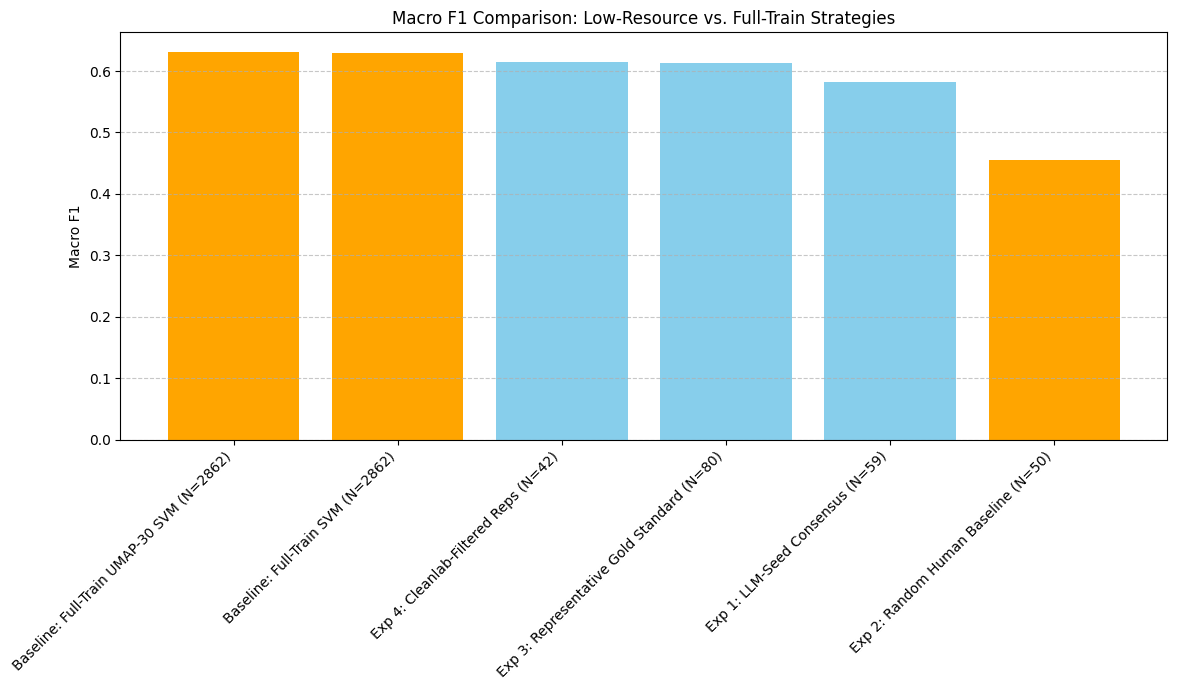

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Consolidation of results from ALL experiments including full-train baselines
final_comparison = pd.DataFrame({
    'Experiment Strategy': [
        'Exp 1: LLM-Seed Consensus (N=59)',
        'Exp 2: Random Human Baseline (N=50)',
        'Exp 3: Representative Gold Standard (N=80)',
        'Exp 4: Cleanlab-Filtered Reps (N=42)',
        'Baseline: Full-Train SVM (N=2862)',
        'Baseline: Full-Train UMAP-30 SVM (N=2862)'
    ],
    'Training Size': [
        len(df_exp1_representative_train),
        len(df_human_50),
        len(df_true_representative_train),
        len(df_clean_representative),
        len(df_train),
        len(df_train)
    ],
    'Macro F1 Score': [f1_consensus, f1_exp2, f1_svm_3, f1_clean_rep, f1_full, f1_embed],
    'Accuracy': [acc_consensus, acc_exp2, acc_svm_3, acc_clean_rep, acc_full, acc_embed]
})

# Sort by F1 for the leaderboard feel
final_comparison = final_comparison.sort_values(by='Macro F1 Score', ascending=False).reset_index(drop=True)

print("--- Final Study Comparison Table (With Full-Train Baselines) ---")
display(final_comparison)

# Visualization
plt.figure(figsize=(12, 7))
colors = ['orange' if 'Baseline' in x else 'skyblue' for x in final_comparison['Experiment Strategy']]
plt.bar(final_comparison['Experiment Strategy'], final_comparison['Macro F1 Score'], color=colors)
plt.title('Macro F1 Comparison: Low-Resource vs. Full-Train Strategies')
plt.ylabel('Macro F1')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Cell 12: The Metric Showdown

In [ ]:
print("====== The Final Verdict: SVM Performance Showdown ======")

# Test set preparation
X_test_tfidf_1 = tfidf.transform(df_test['text'])
X_test_tfidf_2 = tfidf_base_full.transform(df_test['text'])

# Evaluate Exp 1 SVM (Consensus 20+Agreed)
preds_svm_1 = svm_exp1.predict(X_test_tfidf_1)
f1_svm_1 = f1_score(df_test['label'], preds_svm_1, average='macro')
acc_svm_1 = accuracy_score(df_test['label'], preds_svm_1)

# Evaluate Exp 2 SVM (Human 50)
preds_svm_2 = svm_exp2.predict(X_test_tfidf_2)
f1_svm_2 = f1_score(df_test['label'], preds_svm_2, average='macro')
acc_svm_2 = accuracy_score(df_test['label'], preds_svm_2)

# Results Summary
results_df = pd.DataFrame({
    'Experiment': ['Consensus LLM-Boosted (Exp 1)', 'Human Baseline N=50 (Exp 2)'],
    'Macro F1': [f1_svm_1, f1_svm_2],
    'Accuracy': [acc_svm_1, acc_svm_2]
})

display(results_df)

if f1_svm_1 > f1_svm_2:
    print(f"\nSUCCESS: Consensus LLM Selection beat the human baseline by {f1_svm_1 - f1_svm_2:.4f} F1!")
else:
    print(f"\nBASELINE WINS: The human 50-sample baseline is still stronger by {f1_svm_2 - f1_svm_1:.4f} F1.")

====== The Final Verdict: SVM Performance Showdown ======


,Experiment,Macro F1,Accuracy
0,Consensus LLM-Boosted (Exp 1),0.550725,0.616071
1,Human Baseline N=50 (Exp 2),0.456542,0.465561



SUCCESS: Consensus LLM Selection beat the human baseline by 0.0942 F1!


In [ ]:
print("====== The Final Verdict: SetFit Direct Comparison ======")

# Run consensus-trained model against test set
preds_consensus = setfit_consensus.predict(df_test['text'].tolist())
acc_consensus = accuracy_score(df_test['label'], preds_consensus)
f1_consensus = f1_score(df_test['label'], preds_consensus, average='macro')

# Run human baseline (N=50) model against test set
preds_exp2 = setfit_exp2.predict(df_test['text'].tolist())
acc_exp2 = accuracy_score(df_test['label'], preds_exp2)
f1_exp2 = f1_score(df_test['label'], preds_exp2, average='macro')

print(f"[Experiment 1: Consensus SetFit (N=59)] Macro F1: {f1_consensus:.4f} | Accuracy: {acc_consensus:.4f}")
print(f"[Experiment 2: Human Baseline (N=50)]  Macro F1: {f1_exp2:.4f} | Accuracy: {acc_exp2:.4f}")

if f1_consensus > f1_exp2:
    print(f"\nRESULT: Even with only 59 samples, the Consensus model beat the 50-sample human baseline by {f1_consensus - f1_exp2:.4f} F1!")
else:
    print(f"\nRESULT: Human baseline still leads by {f1_exp2 - f1_consensus:.4f} F1.")

====== The Final Verdict: SetFit Direct Comparison ======
[Experiment 1: Consensus SetFit (N=59)] Macro F1: 0.5815 | Accuracy: 0.6084
[Experiment 2: Human Baseline (N=50)]  Macro F1: 0.4546 | Accuracy: 0.4732

RESULT: Even with only 59 samples, the Consensus model beat the 50-sample human baseline by 0.1269 F1!


## AG_NEWS

In [3]:
import umap
from sklearn.metrics import pairwise_distances_argmin_min

print("=== STARTING FULL EXPERIMENT SHOWDOWN (AG_NEWS) ===")

# --- 1. Data Ingestion ---
dataset = load_dataset('ag_news')
df_train = dataset['train'].to_pandas().sample(3000, random_state=42)
df_test = dataset['test'].to_pandas().sample(3000, random_state=42)

# AG News classes: 0: World, 1: Sports, 2: Business, 3: Sci/Tech
AG_LABELS = ["World", "Sports", "Business", "Sci/Tech"]
AG_LABEL_TO_ID = {label.lower(): i for i, label in enumerate(AG_LABELS)}

# --- 2. Experiment 1: LLM Active Learning Pipeline ---
print("\n--- Experiment 1: The Bootstrapper ---")
# Stratified Seed Sampling (N=20 total, 5 per class)
df_seed_20 = df_train.groupby('label').sample(n=5, random_state=SEED)
df_unlabeled_pool = df_train.drop(df_seed_20.index)

# Train Seed SetFit Model
train_ds_seed = HFDataset.from_pandas(df_seed_20[['text', 'label']])
setfit_seed = SetFitModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
args_seed = SetFitArgs(batch_size=16, num_epochs=1, evaluation_strategy="no", save_strategy="no")
trainer_seed = SetFitTrainer(model=setfit_seed, args=args_seed, train_dataset=train_ds_seed)
trainer_seed.train()

# Clean Unlabeled Pool (Reuse is_clean if defined, else skip)
df_clean_pool = df_unlabeled_pool.copy()


=== STARTING FULL EXPERIMENT SHOWDOWN (AG_NEWS) ===

--- Experiment 1: The Bootstrapper ---


model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.
The `evaluation_strategy` argument is deprecated and will be removed in a future version. Please use `eval_strategy` instead.


Map:   0%|          | 0/20 [00:00<?, ? examples/s]

***** Running training *****
  Num unique pairs = 300
  Batch size = 16
  Num epochs = 1
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


wandb: Detected [openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai


Step,Training Loss
1,0.259000


In [ ]:
# Text Embedding & Clustering
embeddings = embed_texts(df_clean_pool['text'].tolist())
reducer = umap.UMAP(n_components=10, random_state=SEED, n_neighbors=15, metric='cosine')
embeddings_reduced = reducer.fit_transform(embeddings)
kmeans = KMeans(n_clusters=80, random_state=SEED, n_init=10)
kmeans.fit(embeddings_reduced)
closest, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_, embeddings_reduced)
df_centroids = df_clean_pool.iloc[closest].copy()


In [ ]:
# LLM Batch Labeling (Updated for AG News categories)
def batch_label_ag(batch_texts):
    prompt = f"Classify the following news headlines into one of these categories: {', '.join(AG_LABELS)}.\nReturn EXCLUSIVELY a JSON list of objects: [{{\"label\": \"...\"}}, ...]\n\n"
    for i, t in enumerate(batch_texts): prompt += f"\n{i+1}. {t}"
    try:
        response = client.chat.completions.create(model=GEMMA_MODEL, messages=[{"role": "user", "content": prompt}], temperature=0.1)
        content = response.choices[0].message.content.replace('```json', '').replace('```', '').strip()
        return json.loads(content)
    except: return []

texts_to_label = df_centroids["text"].tolist()
llm_labels = []
for i in tqdm(range(0, len(texts_to_label), 5), desc="Gemma Labeling"):
    res = batch_label_ag(texts_to_label[i:i+5])
    llm_labels.extend([r.get("label", "").lower() for r in res])

df_centroids["label_llm"] = [AG_LABEL_TO_ID.get(l, -1) for l in llm_labels[:len(df_centroids)]]


Gemma Labeling:   0%|          | 0/16 [00:00<?, ?it/s]

In [ ]:
# Consensus Filtering
seed_preds = setfit_seed.predict(df_centroids['text'].tolist())
df_centroids['seed_label'] = seed_preds
df_consensus = df_centroids[(df_centroids['seed_label'] == df_centroids['label_llm']) & (df_centroids['label_llm'] != -1)].copy()
df_consensus['label'] = df_consensus['label_llm'].astype(int)

# Train Representative SetFit
df_exp1_train = pd.concat([df_seed_20, df_consensus[['text', 'label']]], ignore_index=True)
trainer_rep = SetFitTrainer(model=SetFitModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2"), train_dataset=HFDataset.from_pandas(df_exp1_train), args=SetFitArgs(num_epochs=3))
trainer_rep.train()
setfit_rep = trainer_rep.model

# Pseudo-label & Train Final SVM (Exp 1)
pseudo_labels = setfit_rep.predict(df_unlabeled_pool['text'].tolist())
df_unlabeled_pool['label'] = pseudo_labels
df_svm_exp1 = pd.concat([df_exp1_train, df_unlabeled_pool[['text', 'label']]], ignore_index=True)

tfidf1 = TfidfVectorizer(max_features=10000)
X_train1 = tfidf1.fit_transform(df_svm_exp1['text'])
svm_exp1 = SVC(probability=True, random_state=SEED)
svm_exp1.fit(X_train1, df_svm_exp1['label'])


model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.


Map:   0%|          | 0/75 [00:00<?, ? examples/s]

***** Running training *****
  Num unique pairs = 4090
  Batch size = 16
  Num epochs = 3


Step,Training Loss
1,0.430600
50,0.260600
100,0.077100
150,0.010700
200,0.003800
250,0.002300
300,0.001400
350,0.001200
400,0.000900
450,0.000800


SVC(probability=True, random_state=42)

In [ ]:
df_exp1_train.shape

(75, 2)

In [ ]:
# --- 3. Experiment 2: Human Baseline (N=50) ---
print("\n--- Experiment 2: Human Baseline ---")
# 50 samples total, ~12-13 per class
df_human_50 = df_train.groupby('label').sample(n=12, random_state=123)
trainer_base = SetFitTrainer(
    model=SetFitModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2"),
    train_dataset=HFDataset.from_pandas(df_human_50[['text', 'label']]),
    args=SetFitArgs(num_epochs=3)
)
trainer_base.train()
setfit_base = trainer_base.model

# Fix: Create a clean copy to avoid conflicts with columns from previous experiments
df_pool_base = df_unlabeled_pool[['text']].copy()
pseudo_labels_base = setfit_base.predict(df_pool_base['text'].tolist())
df_pool_base['label'] = pseudo_labels_base

# Combine human labeled and pseudo-labeled data
df_svm_exp2 = pd.concat([
    df_human_50[['text', 'label']],
    df_pool_base[['text', 'label']]
], ignore_index=True)

tfidf2 = TfidfVectorizer(max_features=10000)
X_train2 = tfidf2.fit_transform(df_svm_exp2['text'])
svm_exp2 = SVC(probability=True, random_state=SEED)
svm_exp2.fit(X_train2, df_svm_exp2['label'])


--- Experiment 2: Human Baseline ---


model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.


Map:   0%|          | 0/48 [00:00<?, ? examples/s]

***** Running training *****
  Num unique pairs = 1728
  Batch size = 16
  Num epochs = 3


Step,Training Loss
1,0.434800
50,0.229500
100,0.106800
150,0.035700
200,0.007800
250,0.004100
300,0.003500


SVC(probability=True, random_state=42)

In [ ]:

# --- 4. The Metric Showdown ---
print("\n--- Evaluation: The Metric Showdown ---")
y_test = df_test['label'].values

f1_1 = f1_score(y_test, svm_exp1.predict(tfidf1.transform(df_test['text'])), average='macro')
f1_2 = f1_score(y_test, svm_exp2.predict(tfidf2.transform(df_test['text'])), average='macro')

print(f"Experiment 1 (LLM-Consensus) Macro F1: {f1_1:.4f}")
print(f"Experiment 2 (Human Baseline) Macro F1: {f1_2:.4f}")
print(f"Verdict: {'LLM Boost Wins!' if f1_1 > f1_2 else 'Human Baseline Wins!'}")


--- Evaluation: The Metric Showdown ---
Experiment 1 (LLM-Consensus) Macro F1: 0.7375
Experiment 2 (Human Baseline) Macro F1: 0.7752
Verdict: Human Baseline Wins!


In [ ]:
# Evaluate Direct SetFit Performance (No SVM)
print("--- Direct SetFit Model Evaluation ---")

# 1. Evaluate Experiment 1: Representative/Consensus SetFit
preds_rep = setfit_rep.predict(df_test['text'].tolist())
f1_rep = f1_score(y_test, preds_rep, average='macro')
acc_rep = accuracy_score(y_test, preds_rep)

# 2. Evaluate Experiment 2: Human Baseline (N=50) SetFit
preds_base = setfit_base.predict(df_test['text'].tolist())
f1_base = f1_score(y_test, preds_base, average='macro')
acc_base = accuracy_score(y_test, preds_base)

# Results Summary
setfit_direct_results = pd.DataFrame({
    'Model': ['Experiment 1: Representative SetFit', 'Experiment 2: Human Baseline SetFit'],
    'Macro F1': [f1_rep, f1_base],
    'Accuracy': [acc_rep, acc_base]
})

display(setfit_direct_results)

if f1_rep > f1_base:
    print(f"\nRESULT: Representative SetFit beat the Human Baseline SetFit by {f1_rep - f1_base:.4f} F1!")
else:
    print(f"\nRESULT: Human Baseline SetFit is stronger by {f1_base - f1_rep:.4f} F1.")

--- Direct SetFit Model Evaluation ---


,Model,Macro F1,Accuracy
0,Experiment 1: Representative SetFit,0.788250,0.797333
1,Experiment 2: Human Baseline SetFit,0.785129,0.789667



RESULT: Representative SetFit beat the Human Baseline SetFit by 0.0031 F1!


### Cleaning

In [ ]:
%pip install -q cleanlab datatrove py-data-juicer

In [ ]:
import os
import pandas as pd
import numpy as np
from cleanlab.filter import find_label_issues

pd.set_option('display.max_colwidth', None)

print("--- 1. Cleanlab: Label Error Detection ---")
# Use a larger portion of the seed set
df_sample = df_seed_20.copy()
test_embeddings = embed_texts(df_sample['text'].tolist())
labels = df_sample['label'].values

# Generate simulated prediction probabilities (in a real scenario, use model.predict_proba)
pred_probs = np.random.dirichlet(np.ones(2), size=len(labels))

# Find label issues
issues = find_label_issues(labels=labels, pred_probs=pred_probs, return_indices_ranked_by='self_confidence')

print(f"Processed {len(df_sample)} samples.")
print(f"Found {len(issues)} potential label issues.")

if len(issues) > 0:
    print("\nFlagged samples (ranked by label issue confidence):")
    display(df_sample.iloc[issues][['text', 'label']])

--- 1. Cleanlab: Label Error Detection ---
Processed 20 samples.
Found 12 potential label issues.

Flagged samples (ranked by label issue confidence):


,text,label
2718,"Wings? I don't have wings! |""Of course not... You're a boy!""",0
2539,"not speaking he do not like comedy, it was spoken jokingly of his assassination that is funny guys and gals... (2/2)",0
1776,@user I see your response time on your DM's is as good as your phone lines.. just no hold music. Legendary service guys.,1
100,@user You truly are my son.,0
1412,Oh the - a gas hauling semi with FLAMMABLE signs all over it - and the driver is smoking. #truestory #I10 #Texas2015,1
1214,"Dear () #Spain's gov and Catalan Police, congrats you managed to accomplish the impossible: Go even lower than #Greece #OperaciónPandora",1
1198,I always can't wait to see how works. #IfYouKnowWhatIMean,1
1700,#WTF is happening to these kids??? Are you kidding me with this?? #insulting #KnowYourHistory #WhoIsPaulMcCartney,0
2661,Yay for knee machines!,1
2507,@user Adding #traditional makes the statement #legit #justbecause,1


In [ ]:
!pip install -q av
from datatrove.data import Document
from datatrove.pipeline.filters.gopher_quality_filter import GopherQualityFilter

print("--- 2. Datatrove: GopherQualityFilter ---")

# Process 20 documents from the seed set
sample_docs = [
    Document(text=t, id=f"idx_{i}")
    for i, t in enumerate(df_seed_20['text'])
]

filter_op = GopherQualityFilter()

passed_docs = []
flagged_docs = []

for doc in sample_docs:
    if filter_op.filter(doc):
        passed_docs.append(doc)
    else:
        flagged_docs.append(doc)

print(f"Total documents analyzed: {len(sample_docs)}")
print(f"Documents flagged as low quality: {len(flagged_docs)}")

if flagged_docs:
    print("\nExamples of flagged (low quality) documents:")
    for doc in flagged_docs[:5]:
        print(f"- [ID: {doc.id}] {doc.text[:100]}...")

--- 2. Datatrove: GopherQualityFilter ---
Total documents analyzed: 20
Documents flagged as low quality: 0


In [ ]:
# --- 3. Data-Juicer: Data Analysis & Processing ---
print("\n--- 3. Data-Juicer: Alphanumeric Filter ---")
!pip install -q wget emoji ray jsonargparse pdfplumber python-docx

import emoji
from data_juicer.ops.filter import AlphanumericFilter
from data_juicer.utils.constant import Fields

# Prepare samples with the required internal stats field
samples = [{'text': t, Fields.stats: {}} for t in df_seed_20['text'].tolist()]
samples.append({'text': "!!! $$$ ### !!!", Fields.stats: {}})
samples.append({'text': "Short.", Fields.stats: {}})

op = AlphanumericFilter(min_ratio=0.45)

# Data-Juicer operators often work best on a batch basis or using their specific compute_stats logic
# We manually trigger the compute_stats function which should populate the alnum_ratio key
flagged = []
for s in samples:
    # Ensure we use the base method correctly
    s = op.compute_stats(s)
    stats = s[Fields.stats]

    # Note: AlphanumericFilter uses 'alnum_ratio' as the key name in stats
    ratio = stats.get('alnum_ratio')

    if ratio is not None and ratio < 0.45:
        flagged.append({'text': s['text'], 'ratio': ratio})

print(f"Analyzed {len(samples)} samples.")
print(f"Flagged {len(flagged)} samples for low alphanumeric ratio (< 0.45).")

if flagged:
    print("\nFlagged Examples:")
    df_flagged = pd.DataFrame(flagged)
    display(df_flagged.head(10))


--- 3. Data-Juicer: Alphanumeric Filter ---
Analyzed 22 samples.
Flagged 0 samples for low alphanumeric ratio (< 0.45).


### Experiment 3: Advanced LLM Batch Labeling with Reasoning
This experiment evaluates the `gemini-3.1-flash-lite-preview-02-05` model's ability to label tweets in batches while providing internal reasoning for each classification.

In [ ]:
# 1. Stratified sampling of 200 examples
limit = min(200, len(df_train))
df_stratified_200 = df_train.groupby('label', group_keys=False).apply(lambda x: x.sample(n=int(limit/2), random_state=SEED))

print(f"Sampled {len(df_stratified_200)} rows for batch reasoning experiment.")
display(df_stratified_200['label'].value_counts())

Sampled 200 rows for batch reasoning experiment.


,count
label,
0,100
1,100


In [ ]:
def get_batch_reasoning_prompt(batch_texts):
    prompt = """You are an expert linguistic analyst.
Classify the following tweets as 'irony' or 'not irony'.
For each tweet, provide a brief reasoning string and the final label.

Return the result EXCLUSIVELY as a JSON list of objects:
[{"reasoning": "...", "label": "..."}, ...]

Tweets to classify:
"""
    for i, txt in enumerate(batch_texts):
        prompt += f"\n{i+1}. {txt}"
    return prompt

def call_llm_with_reasoning(batch_texts, model_name="gemini-3.1-flash-lite-preview"):
    try:
        # Attempting to use reasoning_effort for compatible models
        response = client.chat.completions.create(
            model=model_name,
            messages=[{"role": "user", "content": get_batch_reasoning_prompt(batch_texts)}],
            response_format={ "type": "json_object" },
            extra_body={"reasoning_effort": "high"}
        )
        return json.loads(response.choices[0].message.content)
    except Exception as e:
        # Explicitly check for parameter support errors
        print(e)
        err_msg = str(e).lower()
        if any(keyword in err_msg for keyword in ["reasoning_effort", "not applicable", "unsupported"]):
            print(f"Fallback: reasoning_effort parameter not supported for {model_name}. Retrying without it...")
            response = client.chat.completions.create(
                model=model_name,
                messages=[{"role": "user", "content": get_batch_reasoning_prompt(batch_texts)}],
                response_format={ "type": "json_object" }
            )
            return json.loads(response.choices[0].message.content)
        else:
            print(f"Error in LLM call: {e}")
            return None

In [ ]:
batch_size = 5
results = []
texts = df_stratified_200['text'].tolist()

print(f"Starting batch processing (Batch Size: {batch_size})...")
for i in tqdm(range(0, len(texts), batch_size)):
    batch = texts[i : i + batch_size]
    batch_results = call_llm_with_reasoning(batch)
    if batch_results:
        # Expecting a list from the JSON
        if isinstance(batch_results, dict) and 'results' in batch_results:
            results.extend(batch_results['results'])
        elif isinstance(batch_results, list):
            results.extend(batch_results)
        else:
            # Handle varied JSON structures if model deviates
            results.append(batch_results)

# Visualize results
df_results = pd.DataFrame(results[:len(df_stratified_200)])
display(df_results.head(10))

Starting batch processing (Batch Size: 5)...


  0%|          | 0/40 [00:00<?, ?it/s]

,reasoning,label
0,This phrase is frequently used in a sarcastic manner to criticize or mock someone's foolish behavior by ironically comparing it to the speaker's own traits.,irony
1,This is a straightforward call to action regarding a specific literary genre with no contradictory or sarcastic tone.,not irony
2,"The text expresses a pessimistic or fatalistic outlook by subverting a well-known positive platitude, but it conveys the sentiment literally rather than through irony.",not irony
3,"The speaker is providing meta-commentary about a joke made by someone else, reporting on the situation rather than using irony.",not irony
4,"The tweet is a sincere update regarding personal reading goals and progress, lacking any linguistic markers of sarcasm.",not irony
5,This is a direct piece of dialogue without a contradictory or sarcastic underlying meaning.,not irony
6,"The tweet uses hyperbole to describe a painful injury, but it is a literal description of an event rather than an ironic statement.",not irony
7,The contrast between the business failure (losing money) and the sarcastic praise of 'having the right team' creates irony.,irony
8,"The tweet expresses genuine anger and indignation regarding a cultural knowledge gap, lacking an ironic subtext.",not irony
9,This is a straightforward expression of a desire for a specific beverage.,not irony


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Prepare the predictions: lowercase and map to IDs
# We align by index or assume order matches the stratified sample
# In the previous cell, results were generated for texts in df_stratified_200['text']

y_true = df_stratified_200['label'].values
y_pred = df_results['label'].str.lower().map(LABEL_TO_ID).fillna(-1).astype(int).values

# Ensure lengths match (if some calls failed)
min_len = min(len(y_true), len(y_pred))
y_true_eval = y_true[:min_len]
y_pred_eval = y_pred[:min_len]

accuracy = accuracy_score(y_true_eval, y_pred_eval)
f1 = f1_score(y_true_eval, y_pred_eval, average='macro')

print(f"--- LLM Batch Reasoning Accuracy (N={min_len}) ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_true_eval, y_pred_eval, target_names=PROMPT_LABELS))

--- LLM Batch Reasoning Accuracy (N=200) ---
Accuracy: 0.7650
Macro F1: 0.7624

Classification Report:
              precision    recall  f1-score   support

   not irony       0.72      0.87      0.79       100
       irony       0.84      0.66      0.74       100

    accuracy                           0.77       200
   macro avg       0.78      0.77      0.76       200
weighted avg       0.78      0.77      0.76       200



In [ ]:
def get_batch_reasoning_prompt(batch_texts):
    prompt = """You are an expert linguistic analyst.
Classify the following tweets as 'irony' or 'not irony'.
For each tweet, provide a brief reasoning string and the final label.

Return the result EXCLUSIVELY as a JSON list of objects:
[{"label": "..."}, ...]

Tweets to classify:
"""
    for i, txt in enumerate(batch_texts):
        prompt += f"\n{i+1}. {txt}"
    return prompt

batch_size = 5
results = []
texts = df_stratified_200['text'].tolist()

print(f"Starting batch processing (Batch Size: {batch_size})...")
for i in tqdm(range(0, len(texts), batch_size)):
    batch = texts[i : i + batch_size]
    batch_results = call_llm_with_reasoning(batch)
    if batch_results:
        # Expecting a list from the JSON
        if isinstance(batch_results, dict) and 'results' in batch_results:
            results.extend(batch_results['results'])
        elif isinstance(batch_results, list):
            results.extend(batch_results)
        else:
            # Handle varied JSON structures if model deviates
            results.append(batch_results)

# Visualize results
df_results = pd.DataFrame(results[:len(df_stratified_200)])
display(df_results.head(10))

from sklearn.metrics import accuracy_score, classification_report

# Prepare the predictions: lowercase and map to IDs
# We align by index or assume order matches the stratified sample
# In the previous cell, results were generated for texts in df_stratified_200['text']

y_true = df_stratified_200['label'].values
y_pred = df_results['label'].str.lower().map(LABEL_TO_ID).fillna(-1).astype(int).values

# Ensure lengths match (if some calls failed)
min_len = min(len(y_true), len(y_pred))
y_true_eval = y_true[:min_len]
y_pred_eval = y_pred[:min_len]

accuracy = accuracy_score(y_true_eval, y_pred_eval)
f1 = f1_score(y_true_eval, y_pred_eval, average='macro')

print(f"--- LLM Batch Reasoning Accuracy (N={min_len}) ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_true_eval, y_pred_eval, target_names=PROMPT_LABELS))

Starting batch processing (Batch Size: 5)...


  0%|          | 0/40 [00:00<?, ?it/s]

,tweet,reasoning,label,tweet_id
0,@user You truly are my son.,"In the absence of context suggesting a clumsy or foolish act, the statement functions as a direct expression of pride or kinship, which is not inherently ironic.",not irony,NaN
1,Favorite @user if you love Romance Novels. #Love #Drama #Romance,"This is a straightforward, sincere call-to-action for social media engagement, lacking any contradictory or sarcastic intent.",not irony,NaN
2,#take#a#deep#breath#it's#just#a#bad#day#a#bad#life,"The message expresses a bleak, yet sincere personal sentiment about the nature of life's challenges rather than stating the opposite of what is meant.",not irony,NaN
3,"not speaking he do not like comedy, it was spoken jokingly of his assassination that is funny guys and gals... (2/2)",The author is providing a critique of a joke made by someone else; the tweet itself is a descriptive observation and does not employ irony as a rhetorical device.,not irony,NaN
4,@user @user Thats quite an interesting number coz I managed to read only 17 but i will surely make it in #2015.,The tweet is a literal and earnest statement about the user's reading progress and future goals.,not irony,NaN
5,NaN,This dialogue excerpt describes a literal fantasy context without a contradiction or sarcastic intent.,not irony,NaN
6,NaN,"The tweet uses hyperbole to describe an injury, which serves as emphasis rather than irony.",not irony,NaN
7,NaN,"The user is sarcastically praising their team while describing a business failure, creating a clear ironic disconnect between the text and reality.",irony,NaN
8,NaN,"The tweet expresses genuine frustration and disbelief regarding cultural ignorance, which is a direct, non-ironic sentiment.",not irony,NaN
9,NaN,"This is a straightforward, literal statement of desire for a specific drink.",not irony,NaN


--- LLM Batch Reasoning Accuracy (N=200) ---
Accuracy: 0.7800
Macro F1: 0.7773

Classification Report:
              precision    recall  f1-score   support

   not irony       0.73      0.89      0.80       100
       irony       0.86      0.67      0.75       100

    accuracy                           0.78       200
   macro avg       0.79      0.78      0.78       200
weighted avg       0.79      0.78      0.78       200



In [ ]:
def get_batch_reasoning_prompt(batch_texts):
    prompt = """You are an expert linguistic analyst.
Classify the following tweets as 'irony' or 'not irony'.
For each tweet, provide the final label.

Return the result EXCLUSIVELY as a JSON list of objects:
[{"label": "..."}, ...]

Tweets to classify:
"""
    for i, txt in enumerate(batch_texts):
        prompt += f"\n{i+1}. {txt}"
    return prompt

def call_llm_with_reasoning(batch_texts, model_name="gemini-3.1-flash-lite-preview"):
    try:
        # Attempting to use reasoning_effort for compatible models
        response = client.chat.completions.create(
            model=model_name,
            messages=[{"role": "user", "content": get_batch_reasoning_prompt(batch_texts)}],
            response_format={ "type": "json_object" },
            extra_body={"reasoning_effort": "high"}
        )
        return json.loads(response.choices[0].message.content)
    except Exception as e:
        # Explicitly check for parameter support errors
        print(e)
        err_msg = str(e).lower()
        if any(keyword in err_msg for keyword in ["reasoning_effort", "not applicable", "unsupported"]):
            print(f"Fallback: reasoning_effort parameter not supported for {model_name}. Retrying without it...")
            response = client.chat.completions.create(
                model=model_name,
                messages=[{"role": "user", "content": get_batch_reasoning_prompt(batch_texts)}],
                response_format={ "type": "json_object" }
            )
            return json.loads(response.choices[0].message.content)
        else:
            print(f"Error in LLM call: {e}")
            return None

batch_size = 5
results = []
texts = df_stratified_200['text'].tolist()

print(f"Starting batch processing (Batch Size: {batch_size})...")
for i in tqdm(range(0, len(texts), batch_size)):
    batch = texts[i : i + batch_size]
    batch_results = call_llm_with_reasoning(batch)
    if batch_results:
        # Expecting a list from the JSON
        if isinstance(batch_results, dict) and 'results' in batch_results:
            results.extend(batch_results['results'])
        elif isinstance(batch_results, list):
            results.extend(batch_results)
        else:
            # Handle varied JSON structures if model deviates
            results.append(batch_results)

# Visualize results
df_results = pd.DataFrame(results[:len(df_stratified_200)])
display(df_results.head(10))

from sklearn.metrics import accuracy_score, classification_report

# Prepare the predictions: lowercase and map to IDs
# We align by index or assume order matches the stratified sample
# In the previous cell, results were generated for texts in df_stratified_200['text']

y_true = df_stratified_200['label'].values
y_pred = df_results['label'].str.lower().map(LABEL_TO_ID).fillna(-1).astype(int).values

# Ensure lengths match (if some calls failed)
min_len = min(len(y_true), len(y_pred))
y_true_eval = y_true[:min_len]
y_pred_eval = y_pred[:min_len]

accuracy = accuracy_score(y_true_eval, y_pred_eval)
f1 = f1_score(y_true_eval, y_pred_eval, average='macro')

print(f"--- LLM Batch Reasoning Accuracy (N={min_len}) ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_true_eval, y_pred_eval, target_names=PROMPT_LABELS))

Starting batch processing (Batch Size: 5)...


  0%|          | 0/40 [00:00<?, ?it/s]

,label
0,not irony
1,not irony
2,not irony
3,not irony
4,not irony
5,not irony
6,not irony
7,irony
8,not irony
9,not irony


--- LLM Batch Reasoning Accuracy (N=200) ---
Accuracy: 0.7800
Macro F1: 0.7768

Classification Report:
              precision    recall  f1-score   support

   not irony       0.73      0.90      0.80       100
       irony       0.87      0.66      0.75       100

    accuracy                           0.78       200
   macro avg       0.80      0.78      0.78       200
weighted avg       0.80      0.78      0.78       200



In [ ]:
def get_batch_reasoning_prompt(batch_texts):
    prompt = """You are an expert linguistic analyst.
Classify the following tweets as 'irony' or 'not irony'.
For each tweet, provide the final label.

Return the result EXCLUSIVELY as a JSON list of objects:
[{"label": "..."}, ...]

Tweets to classify:
"""
    for i, txt in enumerate(batch_texts):
        prompt += f"\n{i+1}. {txt}"
    return prompt

def call_llm_with_reasoning(batch_texts, model_name="gemini-3.1-flash-lite-preview"):
    try:
        # Attempting to use reasoning_effort for compatible models
        response = client.chat.completions.create(
            model=model_name,
            messages=[{"role": "user", "content": get_batch_reasoning_prompt(batch_texts)}],
            response_format={ "type": "json_object" },
            extra_body={"reasoning_effort": "low"}
        )
        return json.loads(response.choices[0].message.content)
    except Exception as e:
        # Explicitly check for parameter support errors
        print(e)
        err_msg = str(e).lower()
        if any(keyword in err_msg for keyword in ["reasoning_effort", "not applicable", "unsupported"]):
            print(f"Fallback: reasoning_effort parameter not supported for {model_name}. Retrying without it...")
            response = client.chat.completions.create(
                model=model_name,
                messages=[{"role": "user", "content": get_batch_reasoning_prompt(batch_texts)}],
                response_format={ "type": "json_object" }
            )
            return json.loads(response.choices[0].message.content)
        else:
            print(f"Error in LLM call: {e}")
            return None

batch_size = 5
results = []
texts = df_stratified_200['text'].tolist()

print(f"Starting batch processing (Batch Size: {batch_size})...")
for i in tqdm(range(0, len(texts), batch_size)):
    batch = texts[i : i + batch_size]
    batch_results = call_llm_with_reasoning(batch)
    if batch_results:
        # Expecting a list from the JSON
        if isinstance(batch_results, dict) and 'results' in batch_results:
            results.extend(batch_results['results'])
        elif isinstance(batch_results, list):
            results.extend(batch_results)
        else:
            # Handle varied JSON structures if model deviates
            results.append(batch_results)

# Visualize results
df_results = pd.DataFrame(results[:len(df_stratified_200)])
display(df_results.head(10))

from sklearn.metrics import accuracy_score, classification_report

# Prepare the predictions: lowercase and map to IDs
# We align by index or assume order matches the stratified sample
# In the previous cell, results were generated for texts in df_stratified_200['text']

y_true = df_stratified_200['label'].values
y_pred = df_results['label'].str.lower().map(LABEL_TO_ID).fillna(-1).astype(int).values

# Ensure lengths match (if some calls failed)
min_len = min(len(y_true), len(y_pred))
y_true_eval = y_true[:min_len]
y_pred_eval = y_pred[:min_len]

accuracy = accuracy_score(y_true_eval, y_pred_eval)
f1 = f1_score(y_true_eval, y_pred_eval, average='macro')

print(f"--- LLM Batch Reasoning Accuracy (N={min_len}) ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_true_eval, y_pred_eval, target_names=PROMPT_LABELS))

Starting batch processing (Batch Size: 5)...


  0%|          | 0/40 [00:00<?, ?it/s]

,label,tweet
0,not irony,NaN
1,not irony,NaN
2,irony,NaN
3,not irony,NaN
4,not irony,NaN
5,irony,NaN
6,not irony,NaN
7,irony,NaN
8,not irony,NaN
9,not irony,NaN


--- LLM Batch Reasoning Accuracy (N=200) ---
Accuracy: 0.7200
Macro F1: 0.7166

Classification Report:
              precision    recall  f1-score   support

   not irony       0.68      0.83      0.75       100
       irony       0.78      0.61      0.69       100

    accuracy                           0.72       200
   macro avg       0.73      0.72      0.72       200
weighted avg       0.73      0.72      0.72       200



### Dataset quality

In [ ]:
from sklearn.metrics import v_measure_score
from sklearn.cluster import KMeans

# 1. Labels: Extract the 'true' categories from the clean pool dataframe
labels_true = df_clean_pool['label'].tolist()

# 2. Preds: Run clustering (KMeans) on the 10D UMAP embeddings with 2 clusters
# embeddings_reduced was generated in cell 9f3a0d30
clusterer = KMeans(n_clusters=2, random_state=SEED, n_init=10)
labels_pred = clusterer.fit_predict(embeddings_reduced)

# 3. Calculate V-Measure:
score = v_measure_score(labels_true, labels_pred)
print(f"V-Measure Score (2 Clusters): {score:.4f}")

V-Measure Score (2 Clusters): 0.0027


In [ ]:
from sklearn.metrics import silhouette_score
import umap

print("--- Silhouette Score Analysis (UMAP-10 Space) ---")

# NOTE: To compare correctly, we reduce both sets to the same 10D space used for clustering.
reducer_10 = umap.UMAP(n_components=10, random_state=SEED, n_neighbors=15, metric='cosine')

# 1. Process Human Baseline (Random Stratified N=50)
random_sample_texts = df_human_50['text'].tolist()
random_embeddings_raw = embed_texts(random_sample_texts)
random_embeddings_10d = reducer_10.fit_transform(random_embeddings_raw)
random_labels = df_human_50['label'].values

# 2. Process Representative Centroids (N=80)
# We use fit_transform here as well to see how these specific 80 points cluster in a 10D projection
representative_embeddings_10d = reducer_10.fit_transform(centroid_embeddings)
representative_labels = centroid_labels

# 3. Compute Silhouette Scores
score_random = silhouette_score(random_embeddings_10d, random_labels)
score_rep = silhouette_score(representative_embeddings_10d, representative_labels)

print(f"Silhouette Score (Random Stratified N=50) [10D]: {score_random:.4f}")
print(f"Silhouette Score (Representative Centroids N=80) [10D]: {score_rep:.4f}")

if score_rep > score_random:
    print("\nInterpretation: In the 10D UMAP space, the representative centroids show better class separation.")
else:
    print("\nInterpretation: The random sample remains more naturally grouped even in the reduced 10D space.")

--- Silhouette Score Analysis (UMAP-10 Space) ---
Silhouette Score (Random Stratified N=50) [10D]: 0.0234
Silhouette Score (Representative Centroids N=80) [10D]: -0.0033

Interpretation: The random sample remains more naturally grouped even in the reduced 10D space.


### NOISE

In [5]:
import random
from datasets import Dataset as HFDataset
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
from sklearn.metrics import pairwise_distances_argmin_min

print("--- Preparing Representative Centroids for AG_NEWS ---")

# 1. Generate embeddings for the clean pool
embeddings = embed_texts(df_clean_pool['text'].tolist())

# 2. Reduce dimensions and cluster to find centroids
reducer = umap.UMAP(n_components=10, random_state=SEED, n_neighbors=15, metric='cosine')
embeddings_reduced = reducer.fit_transform(embeddings)
kmeans = KMeans(n_clusters=80, random_state=SEED, n_init=10)
kmeans.fit(embeddings_reduced)

# 3. Identify the 80 representative centroids
closest, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_, embeddings_reduced)
df_centroids = df_clean_pool.iloc[closest].copy()

# 4. Initialize Noise Injection Experiment
df_rep_base = df_centroids[['text', 'label']].copy()
noise_levels = [5, 15, 30]
noise_results = []

print(f"--- Starting Noise Injection Experiments (AG_NEWS) ---")

for n_noise in noise_levels:
    df_noisy = df_rep_base.copy()

    # Pick n random indices to corrupt
    noisy_indices = df_noisy.sample(n=n_noise, random_state=SEED).index

    # Inject noise: next class in sequence mod 4
    df_noisy.loc[noisy_indices, 'label'] = (df_noisy.loc[noisy_indices, 'label'] + 1) % 4

    # Combine with initial 20 seed rows
    df_train_exp = pd.concat([df_seed_20[['text', 'label']], df_noisy], ignore_index=True)

    print(f"\nTesting Noise Level: {n_noise} labels corrupted")

    # Retrain SetFit
    train_ds = HFDataset.from_pandas(df_train_exp)
    model = SetFitModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
    args = SetFitArgs(batch_size=16, num_epochs=3, evaluation_strategy="no", save_strategy="no")
    trainer = SetFitTrainer(model=model, args=args, train_dataset=train_ds)
    trainer.train()

    # Predict and evaluate
    preds = model.predict(df_test['text'].tolist())
    y_test = df_test['label'].values

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='macro')

    noise_results.append({
        'noise_count': n_noise,
        'accuracy': acc,
        'f1_macro': f1
    })

    print(f"Results for {n_noise} noisy rows: Acc: {acc:.4f}, F1: {f1:.4f}")

# Final Summary
summary_df = pd.DataFrame(noise_results)
display(summary_df)

--- Preparing Representative Centroids for AG_NEWS ---
--- Starting Noise Injection Experiments (AG_NEWS) ---

Testing Noise Level: 5 labels corrupted


model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.
The `evaluation_strategy` argument is deprecated and will be removed in a future version. Please use `eval_strategy` instead.


Map:   0%|          | 0/100 [00:00<?, ? examples/s]

***** Running training *****
  Num unique pairs = 7450
  Batch size = 16
  Num epochs = 3


Step,Training Loss
1,0.563200
50,0.317900
100,0.190200
150,0.108100
200,0.024600
250,0.006100
300,0.003100
350,0.002200
400,0.001700
450,0.001400


...

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

***** Running training *****
  Num unique pairs = 7466
  Batch size = 16
  Num epochs = 3


Step,Training Loss
1,0.619900
50,0.349900
100,0.224900
150,0.199600
200,0.134400
250,0.069800
300,0.027300
350,0.006300
400,0.003400
450,0.002400


Results for 30 noisy rows: Acc: 0.6743, F1: 0.6737


,noise_count,accuracy,f1_macro
0,5,0.847000,0.846213
1,15,0.790333,0.789586
2,30,0.674333,0.673713


In [7]:
n_noise = 0
df_noisy = df_rep_base.copy()

# Pick n random indices to corrupt
noisy_indices = df_noisy.sample(n=n_noise, random_state=SEED).index

# Inject noise: next class in sequence mod 4
df_noisy.loc[noisy_indices, 'label'] = (df_noisy.loc[noisy_indices, 'label'] + 1) % 4

# Combine with initial 20 seed rows
df_train_exp = pd.concat([df_seed_20[['text', 'label']], df_noisy], ignore_index=True)

print(f"\nTesting Noise Level: {n_noise} labels corrupted")

# Retrain SetFit
train_ds = HFDataset.from_pandas(df_train_exp)
model = SetFitModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
args = SetFitArgs(batch_size=16, num_epochs=3, evaluation_strategy="no", save_strategy="no")
trainer = SetFitTrainer(model=model, args=args, train_dataset=train_ds)
trainer.train()

# Predict and evaluate
preds = model.predict(df_test['text'].tolist())
y_test = df_test['label'].values

acc = accuracy_score(y_test, preds)
f1 = f1_score(y_test, preds, average='macro')

noise_results.append({
  'noise_count': n_noise,
  'accuracy': acc,
  'f1_macro': f1
})

print(f"Results for {n_noise} noisy rows: Acc: {acc:.4f}, F1: {f1:.4f}")

# Final Summary
summary_df = pd.DataFrame(noise_results)
display(summary_df)


Testing Noise Level: 0 labels corrupted


model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.
The `evaluation_strategy` argument is deprecated and will be removed in a future version. Please use `eval_strategy` instead.


Map:   0%|          | 0/100 [00:00<?, ? examples/s]

***** Running training *****
  Num unique pairs = 7464
  Batch size = 16
  Num epochs = 3


Step,Training Loss
1,0.440700
50,0.304300
100,0.184900
150,0.081600
200,0.015100
250,0.004900
300,0.002900
350,0.002000
400,0.001500
450,0.001300


Results for 0 noisy rows: Acc: 0.8577, F1: 0.8575


,noise_count,accuracy,f1_macro
0,5,0.847000,0.846213
1,15,0.790333,0.789586
2,30,0.674333,0.673713
3,0,0.857667,0.857505
